# ViT 모델 실습

## 데이터 로드

In [24]:
!pip uninstall transformers
!pip install transformers

Found existing installation: transformers 5.0.0.dev0
Uninstalling transformers-5.0.0.dev0:
  Would remove:
    /usr/local/bin/transformers
    /usr/local/lib/python3.12/dist-packages/transformers-5.0.0.dev0.dist-info/*
    /usr/local/lib/python3.12/dist-packages/transformers/*
Proceed (Y/n)? y
  Successfully uninstalled transformers-5.0.0.dev0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 104.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.1/566.1 kB 45.0 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface-hub 1.0.0rc6
    Uninstalling huggingface-hub-1.0.0rc6:
      Successfully uninstalled huggingface-hub-1.0.0rc6


In [2]:
# FashionMNIST 다운로드
from itertools import chain
from collections import defaultdict
from torch.utils.data import Subset
from torchvision import datasets

# 서브샘플링
def subset_sampler(dataset, classes, max_len):
  target_idx = defaultdict(list) # 기본값이 있는 딕셔너리 클래스
  # 10개의 레이블이 있음
  for idx, label in enumerate(dataset.train_labels):
    target_idx[int(label)].append(idx)

  indices = list(
      chain.from_iterable(
          [target_idx[idx][:max_len] for idx in range(len(classes))]
      )
  )
  return Subset(dataset, indices)

# FashionMNIST 있어서 다운로드 생략
train_dataset=datasets.FashionMNIST(root='/content/drive/MyDrive/Euron Homework/dataset', train=True)
test_dataset=datasets.FashionMNIST(root='/content/drive/MyDrive/Euron Homework/dataset', train=False)

classes=train_dataset.classes
class_to_idx=train_dataset.class_to_idx # 클래스 ID와 클래스가 매핑된 값

print(classes)
print(class_to_idx)

# 클래스마다 천 개의 색인 값 가져옴
# 총 열 개의 클래스 -> 10000, 1000개씩
subset_train_dataset=subset_sampler(train_dataset, classes, 1000)
subset_test_dataset=subset_sampler(test_dataset, classes, 100)

# 개별 데이터 - PIL 이미지+클래스 번호
print(f"Training data size: {len(subset_train_dataset)}")
print(f"Testing data size: {len(subset_test_dataset)}")

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
{'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9}
Training data size: 10000
Testing data size: 1000


/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")


## 데이터 전처리

In [3]:
# 이미지 전처리 - PIL.Image -> Tensor
import torch
from torchvision import transforms
from transformers import AutoProcessor

# AutoImageProcessor: 사전 학습된 ViT 모델로 전처리 진행 / crop, resize 등
image_processor=AutoProcessor.from_pretrained(
    pretrained_model_name_or_path="google/vit-base-patch16-224-in21k"
)

transform=transforms.Compose(
    [transforms.ToTensor(), # 텐서로 변환
     transforms.Resize(size=( # ViT 모델과 이미지 크기 맞춤
         image_processor.size["height"], image_processor.size["width"]
      )),
     transforms.Lambda( # 사용자 정의 함수 클래스
         lambda x: torch.cat([x,x,x],0) # 단일 채널 복제 -> 다중 채널 이미지로 변환
     ),
     transforms.Normalize( # 정규화
         mean=image_processor.image_mean,
         std=image_processor.image_std
     )]
)

print(f"size: {image_processor.size}")
print(f"mean: {image_processor.image_mean}")
print(f"std: {image_processor.image_std}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


size: {'height': 224, 'width': 224}
mean: [0.5, 0.5, 0.5]
std: [0.5, 0.5, 0.5]


- 사전 학습된 모델 <google/vit-base-patch16-224-in21k>

  -> ImageNet-21k 데이터셋 사용해 224x224 이미지 크기, 16개의 이미지 패치를 기반으로 학습됨

- ViT 모델은 Tensor가 아니라 딕셔너리 형식의 데이터를 입력으로 받음

  {"pixel_values": pixel_values, "labels": labels} 형태

In [4]:
# ViT 데이터로더 적용
from torch.utils.data import DataLoader

def collator(data, transform):
  images, labels=zip(*data) # 데이터에서 이미지랑 레이블 뽑음
  pixel_values=torch.stack([transform(image) for image in images]) # 전처리한 픽셀값
   # (배치 크기, 채널 수, 이미지 높이, 이미지 너비)
  labels=torch.tensor([label for label in labels]) # 레이블 텐서
  return {"pixel_values": pixel_values, "labels": labels}

train_dataloader=DataLoader(
    subset_train_dataset,
    batch_size=32, # 배치 사이즈
    shuffle=True, # 섞음
    collate_fn=lambda x: collator(x, transform),
     # 집합 함수: 데이터로더에서 불러온 배치 -> 딕셔너리로 바꿔줌
    drop_last=True
)
valid_dataloader=DataLoader(
    subset_test_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=lambda x: collator(x, transform),
    drop_last=True
)

batch=next(iter(train_dataloader))
for key, value in batch.items():
  print(f"{key}: {value.shape}")

pixel_values: torch.Size([32, 3, 224, 224])
labels: torch.Size([32])


In [4]:
# 사전 학습된 ViT 모델
from transformers import ViTForImageClassification

model=ViTForImageClassification.from_pretrained(
    pretrained_model_name_or_path='google/vit-base-patch16-224-in21k',
    num_labels=len(classes), # 레이블 개수
    id2label={idx: label for label, idx in class_to_idx.items()},
    label2id=class_to_idx,
    ignore_mismatched_sizes=True
)

print(model.classifier)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Linear(in_features=768, out_features=10, bias=True)


21,841개의 분류 카테고리로 학습된 모델 -> 파라미터로 미세 조정 가능

In [5]:
# 패치 임베딩 확인
## 패치 임베딩 함수 - 16x16 커널, stride=16의 Conv2d 연산 수행
## 합성곱 -> 텐서 -> 1차원으로 나열 & 패치로 분할 => 패치 생성
print(model.vit.embeddings)

batch=next(iter(train_dataloader))
print("imgae shape: ", batch["pixel_values"].shape)
print("patch embeddings shape: ",
      # 배치 하나를 패치 임베딩 함수에 적용
      model.vit.embeddings.patch_embeddings(batch["pixel_values"]).shape)

print("[DLS] + patch embeddings shape: ",
      # 임베딩: 197개의 벡터 생성
      model.vit.embeddings(batch["pixel_values"]).shape)

ViTEmbeddings(
  (patch_embeddings): ViTPatchEmbeddings(
    (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  )
  (dropout): Dropout(p=0.0, inplace=False)
)
imgae shape:  torch.Size([32, 3, 224, 224])
patch embeddings shape:  torch.Size([32, 196, 768])
[DLS] + patch embeddings shape:  torch.Size([32, 197, 768])


패치 임베딩 -> 분할한 패치마다 특성을 추출함

## 모델 학습

In [6]:
# 하이퍼파라미터 설정
from transformers import TrainingArguments
 # 하이퍼파라미터 관리, 모델 평가, 분산 학습, 허깅 페이스 허브 연동, 로그 추적 등의 기능 제공

args = TrainingArguments(
    output_dir="/content/drive/MyDrive/Euron Homework/models/ViT-FashionMNIST",
    save_strategy="epoch",
    eval_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.001,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="logs",
    logging_steps=125,
    remove_unused_columns=False,
    seed=7,
    report_to="none" # W&B 설정 off
)

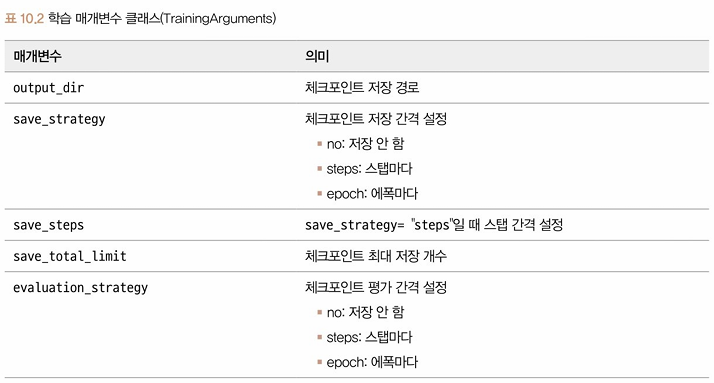

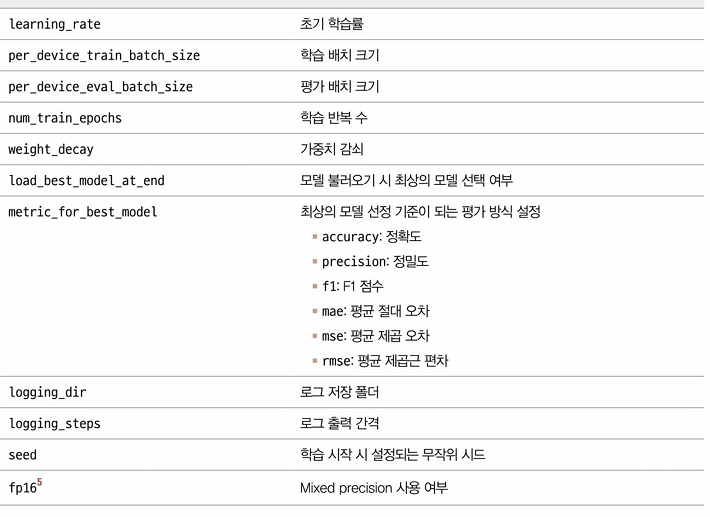

In [7]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00


In [8]:
# 모델 성능 지표 방법 설정 - Macro Average F1-Score
import evaluate
import numpy as np

def compute_metrics(eval_pred): # eval_pred: 모델 예측 결괏값
  metric=evaluate.load("f1")
  predictions, labels=eval_pred
  predictions=np.argmax(predictions, axis=1) # 가장 확률 높은 값 = 예측값
  macro_f1=metric.compute(
      predictions=predictions, references=labels, average="macro"
  )
  return macro_f1

In [9]:
from transformers import Trainer
## 훈련자 클래스: 모델-model_init 함수 형태 / 데이터세트 / 집합 함수 등 전달

def model_init(classes, class_to_idx):
  model=ViTForImageClassification.from_pretrained(
    pretrained_model_name_or_path='google/vit-base-patch16-224-in21k',
    num_labels=len(classes), # 레이블 개수
    id2label={idx: label for label, idx in class_to_idx.items()},
    label2id=class_to_idx,
  )
  return model

# 모델 학습
trainer=Trainer(
    model_init=lambda x: model_init(classes, class_to_idx),
    args=args,
    train_dataset=subset_train_dataset,
    eval_dataset=subset_test_dataset,
    data_collator=lambda x: collator(x, transform),
    compute_metrics=compute_metrics,
    tokenizer=image_processor, # 토큰 임베딩 -> 모델 입력으로 사용할 수 있도록 토큰 분리
)
trainer.train()

/tmp/ipython-input-3943777625.py:14: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer=Trainer(
Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1
1,0.703500,0.636208,0.884436
2,0.477800,0.474130,0.911931
3,0.417700,0.426275,0.925148


TrainOutput(global_step=1875, training_loss=0.6982760803222656, metrics={'train_runtime': 1063.6761, 'train_samples_per_second': 28.204, 'train_steps_per_second': 1.763, 'total_flos': 2.32492637712384e+18, 'train_loss': 0.6982760803222656, 'epoch': 3.0})

PredictionOutput(predictions=array([[ 3.0744958 , -0.63892466, -0.29480687, ..., -0.5712289 ,
        -0.3415205 , -0.61706764],
       [ 2.0577676 , -0.6733721 , -0.26766214, ..., -0.79338837,
        -0.84442043, -0.9861916 ],
       [ 2.9871175 , -0.609895  , -0.1670235 , ..., -0.53217477,
        -0.39715102, -0.6160375 ],
       ...,
       [-0.58543736, -0.621112  , -0.5678751 , ...,  0.60750306,
         0.43795833,  2.9655886 ],
       [-0.55852604, -0.38263613, -0.3029788 , ...,  0.15812834,
        -0.31425494,  3.3983977 ],
       [-0.5375074 , -0.32675332, -0.30132952, ..., -0.27463338,
        -0.15623917,  3.4112313 ]], dtype=float32), label_ids=array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

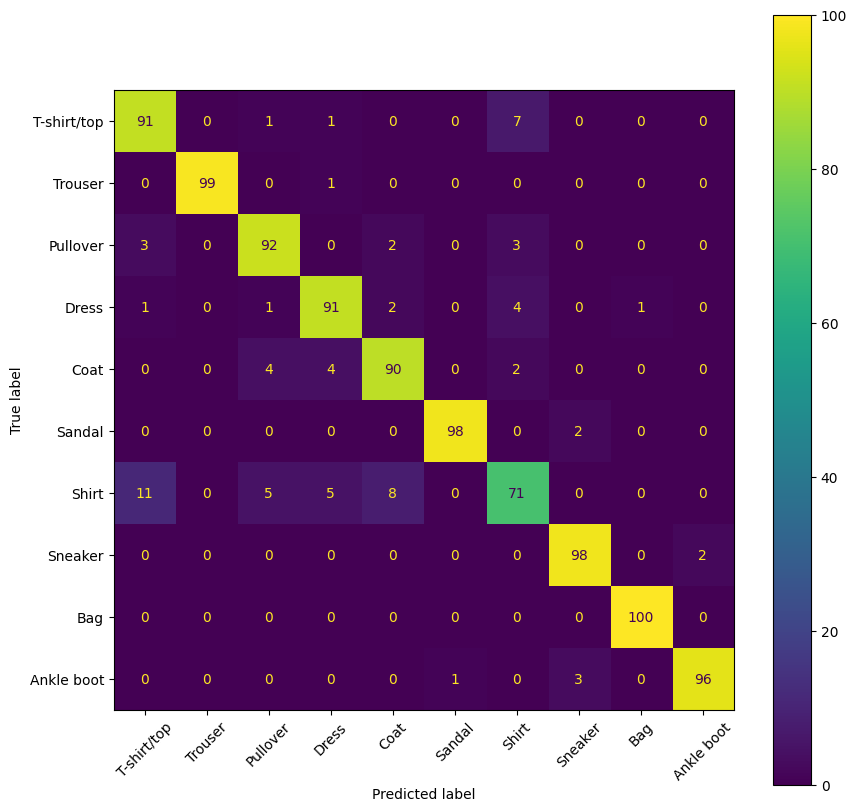

In [10]:
## 예측 성능 평가
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


outputs = trainer.predict(subset_test_dataset)
print(outputs)

y_true = outputs.label_ids
y_pred = outputs.predictions.argmax(1)

labels = list(classes)
matrix = confusion_matrix(y_true, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=labels)
_, ax = plt.subplots(figsize=(10, 10))
display.plot(xticks_rotation=45, ax=ax)
plt.show()

# Swin Transformer 실습

## 전처리 및 모델 다운로드

In [5]:
# 사전 학습된 스윈 트랜스포머 모델
from transformers import SwinForImageClassification


model = SwinForImageClassification.from_pretrained(
    pretrained_model_name_or_path="microsoft/swin-tiny-patch4-window7-224",
    num_labels=len(train_dataset.classes),
    id2label={idx: label for label, idx in train_dataset.class_to_idx.items()},
    label2id=train_dataset.class_to_idx,
    ignore_mismatched_sizes=True
)

for main_name, main_module in model.named_children():
    print(main_name)
    for sub_name, sub_module in main_module.named_children():
        print("└", sub_name)
        for ssub_name, ssub_module in sub_module.named_children():
            print("│  └", ssub_name)
            for sssub_name, sssub_module in ssub_module.named_children():
                if sssub_name == "projection":
                    print("│  │  └", sssub_name, sssub_module)
                else:
                    print("│  │  └", sssub_name)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-tiny-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


swin
└ embeddings
│  └ patch_embeddings
│  │  └ projection Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
│  └ norm
│  └ dropout
└ encoder
│  └ layers
│  │  └ 0
│  │  └ 1
│  │  └ 2
│  │  └ 3
└ layernorm
└ pooler
classifier


- swin: 패치 파티션, 선형 임베딩과 함께 네 개의 스테이지(0,1,2,3) 수행함. 스테이지 이후 계층 정규화(layernorm)와 풀링(pooler) 통과

- classifier: 클래스 구분

In [6]:
# 패치 임베딩 모듈
batch = next(iter(train_dataloader))
print("이미지 차원 :", batch["pixel_values"].shape)

patch_emb_output, shape = model.swin.embeddings.patch_embeddings(batch["pixel_values"])
 ## 패치 파티션, 선형 임베딩 수행
print("모듈:", model.swin.embeddings.patch_embeddings)
 ## kernel=4*4, stride=4
 ## 224x224 이미지 적용 -> 56x56 텐서 생성
print("패치 임베딩 차원 :", patch_emb_output.shape)

이미지 차원 : torch.Size([32, 3, 224, 224])
모듈: SwinPatchEmbeddings(
  (projection): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
)
패치 임베딩 차원 : torch.Size([32, 3136, 96])


3136개 패치 생성, 96개 채널 생성

스윈 트랜스포머에서는 [CLS] 토큰을 사용하지 않고, 토큰들의 평균값을 사용해 분류함. 객체 검출과 같은 작업에서 입력 이미지에 여러 물체가 포함되면 [CLS] 토큰 하나로는 모든 물체를 효과적으로 검출하기 어렵기 때문.

In [7]:
# 스윈 트랜스포머 블록
for main_name, main_module in model.swin.encoder.layers[0].named_children():
    print(main_name)
    for sub_name, sub_module in main_module.named_children():
        print("└", sub_name)
        for ssub_name, ssub_module in sub_module.named_children():
            print("│ └", ssub_name)

blocks
└ 0
│ └ layernorm_before
│ └ attention
│ └ drop_path
│ └ layernorm_after
│ └ intermediate
│ └ output
└ 1
│ └ layernorm_before
│ └ attention
│ └ drop_path
│ └ layernorm_after
│ └ intermediate
│ └ output
downsample
└ reduction
└ norm


- 스테이지 = blocks + downsample
  - blocks: 스윈 트랜스포머 블록
    - SwinLayer-0: W-MSA
    - SwinLayer-1: SW-MSA
  - downsample: 패치 병합

In [8]:
# SwinLayer=스윈 트랜스포머 블록 구조
print(model.swin.encoder.layers[0].blocks[0])

SwinLayer(
  (layernorm_before): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  (attention): SwinAttention(
    (self): SwinSelfAttention(
      (query): Linear(in_features=96, out_features=96, bias=True)
      (key): Linear(in_features=96, out_features=96, bias=True)
      (value): Linear(in_features=96, out_features=96, bias=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (output): SwinSelfOutput(
      (dense): Linear(in_features=96, out_features=96, bias=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
  )
  (drop_path): Identity()
  (layernorm_after): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  (intermediate): SwinIntermediate(
    (dense): Linear(in_features=96, out_features=384, bias=True)
    (intermediate_act_fn): GELUActivation()
  )
  (output): SwinOutput(
    (dense): Linear(in_features=384, out_features=96, bias=True)
    (dropout): Dropout(p=0.0, inplace=False)
  )
)


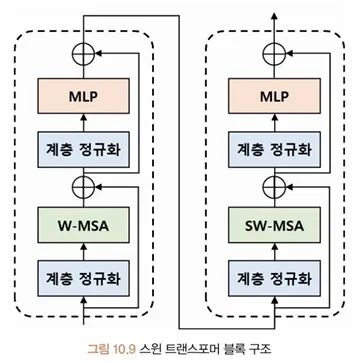

스윈 트랜스포머 블록: 계층 정규화 -> W-MSA/SW-MSA -> 계층 정규화 -> MLP

- layernorm_before: 첫 번째 계층 정규화
- attention: W-MSA(SW-MSA)
- layernorm_after: 두 번째 계층 정규화
- intermediate, output: MLP
  - 두 개의 연속 선형 변환 계층
  - GELU(Gaussian Error Linear Unit) 활성화 함수: 가우시안 분포에 대한 누적 분포 함수로, ReLU와 유사한 형태를 가짐
  
  -> 선형 변환 및 GELU 함수를 통해 입력 피처 맵을 더 깊은 차원으로 매핑하고 ReLU보다 더 안정적으로 학습 수행함

In [11]:
# W-MSA, SW-MSA
print("패치 임베딩 차원 :", patch_emb_output.shape)
W_MSA = model.swin.encoder.layers[0].blocks[0]
SW_MSA = model.swin.encoder.layers[0].blocks[1]

W_MSA_output = W_MSA(patch_emb_output, W_MSA.input_resolution)[0]
SW_MSA_output = SW_MSA(W_MSA_output, SW_MSA.input_resolution)[0]

print("W-MSA 결과 차원 :", W_MSA_output.shape)
print("SW-MSA 결과 차원 :", SW_MSA_output.shape)

패치 임베딩 차원 : torch.Size([32, 3136, 96])
W-MSA 결과 차원 : torch.Size([32, 3136, 96])
SW-MSA 결과 차원 : torch.Size([32, 3136, 96])


In [12]:
# 패치 병합 확인
patch_merge = model.swin.encoder.layers[0].downsample
print("patch_merge 모듈 :", patch_merge)

output = patch_merge(SW_MSA_output, patch_merge.input_resolution)
print("patch_merge 결과 차원 :", output.shape)

patch_merge 모듈 : SwinPatchMerging(
  (reduction): Linear(in_features=384, out_features=192, bias=False)
  (norm): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
)
patch_merge 결과 차원 : torch.Size([32, 784, 192])


패치 병합: 3136 (56x56) 패치 -> 784 (28x28) 개로 분할
- reduction(입력 패치를 절반 크기로 분할) + 계층 정규화

- 분할된 패치를 4개로 나눔 -> 4개의 (N, 28, 28, 96) 텐서 생성

- 채널에 병합: 96x4-384

- 선형 변환 계층: 채널 수를 절반으로 조정 384 -> 192

=> patch_merge 결과: [N, 784, 192]

각 스테이지마다 패치 크기와 수는 많아지고 토큰 차원은 두 배씩 증가함 x 4개의 스테이지

-> [N, 49(7x7), 768]

=> 풀링층 통과 - 클래스 예측

## 데이터에 대해 모델 학습

In [14]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.8 MB/s eta 0:00:00


In [17]:
import torch
import evaluate
import numpy as np
from itertools import chain
from collections import defaultdict
from torch.utils.data import Subset
from torchvision import datasets
from torchvision import transforms
from transformers import AutoImageProcessor
from transformers import SwinForImageClassification
from transformers import TrainingArguments, Trainer


def subset_sampler(dataset, classes, max_len):
    target_idx = defaultdict(list)
    for idx, label in enumerate(dataset.train_labels):
        target_idx[int(label)].append(idx)

    indices = list(
        chain.from_iterable(
            [target_idx[idx][:max_len] for idx in range(len(classes))]
        )
    )
    return Subset(dataset, indices)


def model_init(classes, class_to_idx):
    model = SwinForImageClassification.from_pretrained(
        pretrained_model_name_or_path="microsoft/swin-tiny-patch4-window7-224",
        num_labels=len(classes),
        id2label={idx: label for label, idx in class_to_idx.items()},
        label2id=class_to_idx,
        ignore_mismatched_sizes=True
    )
    return model


def collator(data, transform):
    images, labels = zip(*data)
    pixel_values = torch.stack([transform(image) for image in images])
    labels = torch.tensor([label for label in labels])
    return {"pixel_values": pixel_values, "labels": labels}


def compute_metrics(eval_pred):
    metric = evaluate.load("f1")
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    macro_f1 = metric.compute(
        predictions=predictions, references=labels, average="macro"
    )
    return macro_f1


train_dataset = datasets.FashionMNIST(root="/content/drive/MyDrive/Euron Homework/dataset", train=True)
test_dataset = datasets.FashionMNIST(root="/content/drive/MyDrive/Euron Homework/dataset", train=False)

classes = train_dataset.classes
class_to_idx = train_dataset.class_to_idx

subset_train_dataset = subset_sampler(
    dataset=train_dataset, classes=train_dataset.classes, max_len=1000
)
subset_test_dataset = subset_sampler(
    dataset=test_dataset, classes=test_dataset.classes, max_len=100
)

image_processor = AutoImageProcessor.from_pretrained(
    pretrained_model_name_or_path="microsoft/swin-tiny-patch4-window7-224"
)

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Resize(
            size=(
                image_processor.size["height"],
                image_processor.size["width"]
            )
        ),
        transforms.Lambda(
            lambda x: torch.cat([x, x, x], 0)
        ),
        transforms.Normalize(
            mean=image_processor.image_mean,
            std=image_processor.image_std
        )
    ]
)

args = TrainingArguments(
    output_dir="/content/drive/MyDrive/Euron Homework/models/Swin-FashionMNIST",
    save_strategy="epoch",
    eval_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.001,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="logs",
    logging_steps=125,
    remove_unused_columns=False,
    seed=7,
    report_to="none" # W&B 설정 off
)

trainer = Trainer(
    model_init=lambda x: model_init(classes, class_to_idx),
    args=args,
    train_dataset=subset_train_dataset,
    eval_dataset=subset_test_dataset,
    data_collator=lambda x: collator(x, transform),
    compute_metrics=compute_metrics,
    tokenizer=image_processor,
)
trainer.train()

/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/tmp/ipython-input-1780986368.py:109: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-tiny-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of SwinForImageClassification were not initialized from the model c

Epoch,Training Loss,Validation Loss,F1
1,0.346800,0.293348,0.895520
2,0.246300,0.249463,0.913467
3,0.216000,0.227199,0.925201


TrainOutput(global_step=1875, training_loss=0.36211956481933594, metrics={'train_runtime': 469.4163, 'train_samples_per_second': 63.909, 'train_steps_per_second': 3.994, 'total_flos': 7.4584635826176e+17, 'train_loss': 0.36211956481933594, 'epoch': 3.0})

## 모델 예측 성능 평가

PredictionOutput(predictions=array([[ 8.327117  , -2.9221601 , -0.14725183, ..., -2.0062077 ,
        -1.7702351 , -2.1199894 ],
       [ 4.972095  , -0.19329895,  0.5320294 , ..., -1.7852148 ,
        -1.0379158 , -2.8217747 ],
       [ 7.8400903 , -3.0855646 , -0.5025086 , ..., -1.3670087 ,
         0.27151877, -1.7774279 ],
       ...,
       [-1.0604999 , -3.0514846 , -2.1184323 , ...,  1.1264031 ,
         0.65361995,  4.7537713 ],
       [-0.38998842, -3.0071034 , -1.6316311 , ...,  1.3848708 ,
        -2.7147253 ,  8.766197  ],
       [-1.8107215 , -1.860353  , -1.5863495 , ..., -1.2799532 ,
        -1.7855961 ,  8.132585  ]], dtype=float32), label_ids=array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

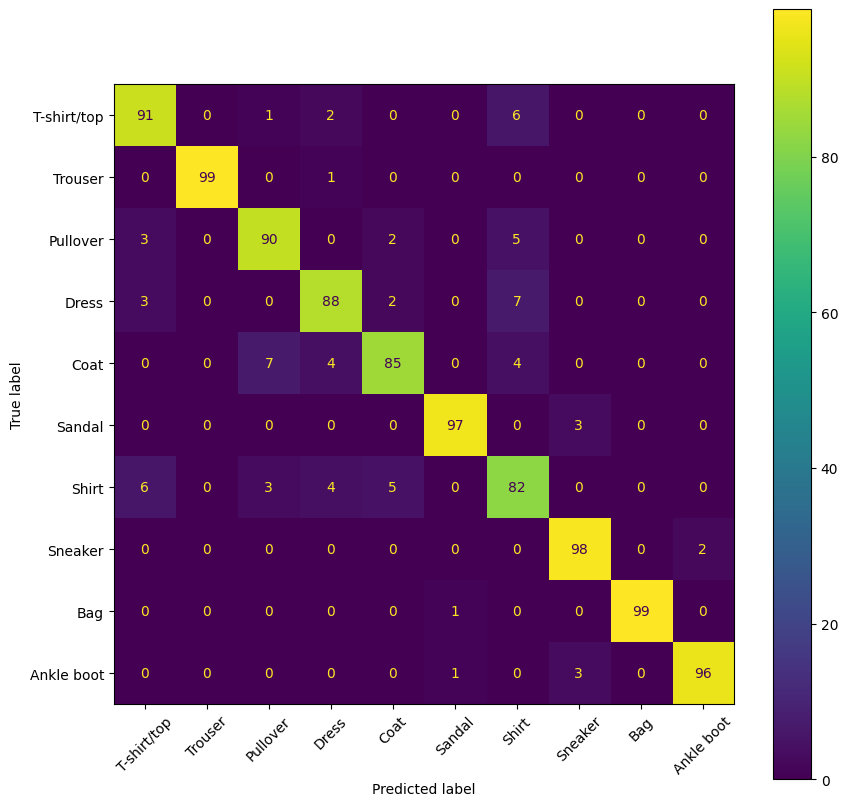

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # 혼동 행렬

outputs = trainer.predict(subset_test_dataset)
print(outputs)

y_true = outputs.label_ids
y_pred = outputs.predictions.argmax(1)

labels = list(classes)
matrix = confusion_matrix(y_true, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=labels)
_, ax = plt.subplots(figsize=(10, 10))
display.plot(xticks_rotation=45, ax=ax)
plt.show()

- ViT에 비해 오분류 문제 완화됨
- ViT에 비해 수렴 속도가 더 빠름

# CvT 실습

## 데이터 전처리 및 모델 로드

In [19]:
from itertools import chain
from collections import defaultdict
from torch.utils.data import Subset
from torchvision import datasets


def subset_sampler(dataset, classes, max_len):
    target_idx = defaultdict(list)
    for idx, label in enumerate(dataset.train_labels):
        target_idx[int(label)].append(idx)

    indices = list(
        chain.from_iterable(
            [target_idx[idx][:max_len] for idx in range(len(classes))]
        )
    )
    return Subset(dataset, indices)


train_dataset = datasets.FashionMNIST(root="../datasets", download=True, train=True)
test_dataset = datasets.FashionMNIST(root="../datasets", download=True, train=False)

classes = train_dataset.classes
class_to_idx = train_dataset.class_to_idx

subset_train_dataset = subset_sampler(
    dataset=train_dataset, classes=train_dataset.classes, max_len=1000
)
subset_test_dataset = subset_sampler(
    dataset=test_dataset, classes=test_dataset.classes, max_len=100
)

/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")


In [20]:
import torch
from torchvision import transforms
from transformers import AutoImageProcessor


image_processor = AutoImageProcessor.from_pretrained(
    pretrained_model_name_or_path="microsoft/cvt-21"
)

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Resize(
            size=(
                image_processor.size["shortest_edge"],
                image_processor.size["shortest_edge"]
                # shortest_edge: 이미지의 너비나 높이 중 더 작은 값으로 정규화
            )
        ),
        transforms.Lambda(lambda x: torch.cat([x, x, x], 0)),
        transforms.Normalize(
            mean=image_processor.image_mean,
            std=image_processor.image_std
        )
    ]
)

preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

In [21]:
from torch.utils.data import DataLoader


def collator(data, transform):
    images, labels = zip(*data)
    pixel_values = torch.stack([transform(image) for image in images])
    labels = torch.tensor([label for label in labels])
    return {"pixel_values": pixel_values, "labels": labels}


train_dataloader = DataLoader(
    subset_train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=lambda x: collator(x, transform),
    drop_last=True
)
valid_dataloader = DataLoader(
    subset_test_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=lambda x: collator(x, transform),
    drop_last=True
)

## CvT 모델 관찰

In [22]:
# 사전 학습된 CvT 모델
from transformers import CvtForImageClassification

model = CvtForImageClassification.from_pretrained(
    pretrained_model_name_or_path="microsoft/cvt-21",
    num_labels=len(train_dataset.classes),
    id2label={idx: label for label, idx in train_dataset.class_to_idx.items()},
    label2id=train_dataset.class_to_idx,
    ignore_mismatched_sizes=True
)

for main_name, main_module in model.named_children():
    print(main_name)
    for sub_name, sub_module in main_module.named_children():
        print("└", sub_name)
        for ssub_name, ssub_module in sub_module.named_children():
            print("   └", ssub_name)
            for sssub_name, sssub_module in ssub_module.named_children():
                print("     └", sssub_name)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/127M [00:00<?, ?B/s]

Some weights of CvtForImageClassification were not initialized from the model checkpoint at microsoft/cvt-21 and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([1000, 384]) in the checkpoint and torch.Size([10, 384]) in the model instantiated
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


cvt
└ encoder
   └ stages
     └ 0
     └ 1
     └ 2
layernorm
classifier


CvT: 세 개의 스테이지로 구성된 cvt + 계층 정규화 + 분류기


- 스윈 트랜스포머와의 차이점
  - 풀링층 X: CvT는 이미 합성곱 계층을 활용해 지역 특징 정보와 전역 정보를 파악하기 때문
  - 스테이지별 이미지 크기: 4배, 8배, 16배 감소
  - 스테이지별 임베딩 차원: 반비례하게 커짐

In [23]:
# CvT 모델의 스테이지 구조
stages = model.cvt.encoder.stages
print(stages[0])

CvtStage(
  (embedding): CvtEmbeddings(
    (convolution_embeddings): CvtConvEmbeddings(
      (projection): Conv2d(3, 64, kernel_size=(7, 7), stride=(4, 4), padding=(2, 2))
      (normalization): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (layers): Sequential(
    (0): CvtLayer(
      (attention): CvtAttention(
        (attention): CvtSelfAttention(
          (convolution_projection_query): CvtSelfAttentionProjection(
            (convolution_projection): CvtSelfAttentionConvProjection(
              (convolution): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
              (normalization): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            )
            (linear_projection): CvtSelfAttentionLinearProjection()
          )
          (convolution_projection_key): CvtSelfAttentionProjection(
            (convolution_projection): CvtSelfAtte

각 스테이지
- CvTEmbeddings: 이미지를 패치 단위로 잘라 임베딩
  - 2D 합성곱 연산: 224x224 입력 이미지 -> 56x56 텐서 생성 (즉 [N, 64, 56, 56])
  - 계층 정규화
- CvtLayer: 3156(56x56)개 이미지 패치에 대한 셀프 어텐션 수행

In [24]:
# 셀프 어텐션 적용
batch = next(iter(train_dataloader))
print("이미지 차원 :", batch["pixel_values"].shape)

patch_emb_output = stages[0].embedding(batch["pixel_values"])
print("패치 임베딩 차원 :", patch_emb_output.shape)

batch_size, num_channels, height, width = patch_emb_output.shape
hidden_state = patch_emb_output.view(batch_size, num_channels, height * width).permute(0, 2, 1)
print("셀프 어텐션 입력 차원 :", hidden_state.shape)

# attention.attention 계층으로 셀프 어텐션 수행
attention_output = stages[0].layers[0].attention.attention(hidden_state, height, width)
print("셀프 어텐션 출력 차원 :", attention_output.shape)

이미지 차원 : torch.Size([32, 3, 224, 224])
패치 임베딩 차원 : torch.Size([32, 64, 56, 56])
셀프 어텐션 입력 차원 : torch.Size([32, 3136, 64])
셀프 어텐션 출력 차원 : torch.Size([32, 3136, 64])


## 모델 학습

In [26]:
import torch
import evaluate
import numpy as np
from itertools import chain
from collections import defaultdict
from torch.utils.data import Subset
from torchvision import datasets
from torchvision import transforms
from transformers import AutoImageProcessor
from transformers import CvtForImageClassification
from transformers import TrainingArguments, Trainer


def subset_sampler(dataset, classes, max_len):
    target_idx = defaultdict(list)
    for idx, label in enumerate(dataset.train_labels):
        target_idx[int(label)].append(idx)

    indices = list(
        chain.from_iterable(
            [target_idx[idx][:max_len] for idx in range(len(classes))]
        )
    )
    return Subset(dataset, indices)


def model_init(classes, class_to_idx):
    model = CvtForImageClassification.from_pretrained(
        pretrained_model_name_or_path="microsoft/cvt-21",
        num_labels=len(classes),
        id2label={idx: label for label, idx in class_to_idx.items()},
        label2id=class_to_idx,
        ignore_mismatched_sizes=True
    )
    return model


def collator(data, transform):
    images, labels = zip(*data)
    pixel_values = torch.stack([transform(image) for image in images])
    labels = torch.tensor([label for label in labels])
    return {"pixel_values": pixel_values, "labels": labels}


def compute_metrics(eval_pred):
    metric = evaluate.load("f1")
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    macro_f1 = metric.compute(
        predictions=predictions, references=labels, average="macro"
    )
    return macro_f1


train_dataset = datasets.FashionMNIST(root="/content/drive/MyDrive/Euron Homework/dataset", train=True)
test_dataset = datasets.FashionMNIST(root="/content/drive/MyDrive/Euron Homework/dataset", train=False)

classes = train_dataset.classes
class_to_idx = train_dataset.class_to_idx

subset_train_dataset = subset_sampler(
    dataset=train_dataset, classes=train_dataset.classes, max_len=1000
)
subset_test_dataset = subset_sampler(
    dataset=test_dataset, classes=test_dataset.classes, max_len=100
)

image_processor = AutoImageProcessor.from_pretrained(
    pretrained_model_name_or_path="microsoft/cvt-21"
)

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Resize(
            size=(
                image_processor.size["shortest_edge"],
                image_processor.size["shortest_edge"]
            )
        ),
        transforms.Lambda(
            lambda x: torch.cat([x, x, x], 0)
        ),
        transforms.Normalize(
            mean=image_processor.image_mean,
            std=image_processor.image_std
        )
    ]
)

args = TrainingArguments(
    output_dir="/content/drive/MyDrive/Euron Homework/models/CvT-FashionMNIST",
    save_strategy="epoch",
    eval_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.001,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="logs",
    logging_steps=125,
    remove_unused_columns=False,
    seed=7,
    report_to="none" # W&B 설정 off
)

trainer = Trainer(
    model_init=lambda x: model_init(classes, class_to_idx),
    args=args,
    train_dataset=subset_train_dataset,
    eval_dataset=subset_test_dataset,
    data_collator=lambda x: collator(x, transform),
    compute_metrics=compute_metrics,
    tokenizer=image_processor,
)
trainer.train()

/tmp/ipython-input-866705428.py:109: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
Some weights of CvtForImageClassification were not initialized from the model checkpoint at microsoft/cvt-21 and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([1000, 384]) in the checkpoint and torch.Size([10, 384]) in the model instantiated
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of CvtForImageClassification were not initialized from the model checkpoint at microsoft/cvt-21 and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([1000, 384]) in the checkpoint and torch.Size([10, 384]) in the model ins

Epoch,Training Loss,Validation Loss,F1
1,0.802500,0.337030,0.883858
2,0.683200,0.277314,0.908333
3,0.667400,0.269117,0.912754


TrainOutput(global_step=1875, training_loss=0.7889007975260417, metrics={'train_runtime': 791.6535, 'train_samples_per_second': 37.895, 'train_steps_per_second': 2.368, 'total_flos': 8.4649093853184e+17, 'train_loss': 0.7889007975260417, 'epoch': 3.0})

## 모델 예측 성능 평가

PredictionOutput(predictions=array([[ 6.8492227 , -1.4205431 ,  0.21264642, ..., -1.3527933 ,
        -0.20525357, -1.7215569 ],
       [ 3.2404246 , -0.7183045 , -0.2527829 , ..., -1.9335936 ,
        -0.82448214, -2.5251439 ],
       [ 7.0844903 , -1.4627521 ,  0.06169155, ..., -1.3343201 ,
        -0.43499786, -1.4694498 ],
       ...,
       [-1.2418569 , -1.3450942 , -0.89107317, ...,  2.092297  ,
        -0.23464079,  4.773835  ],
       [-1.115248  , -0.52287364, -0.19355445, ...,  1.0878437 ,
        -0.8873731 ,  6.9351172 ],
       [-1.7945776 , -0.01695204, -0.57061213, ..., -0.40405762,
        -0.23832993,  7.0236564 ]], dtype=float32), label_ids=array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

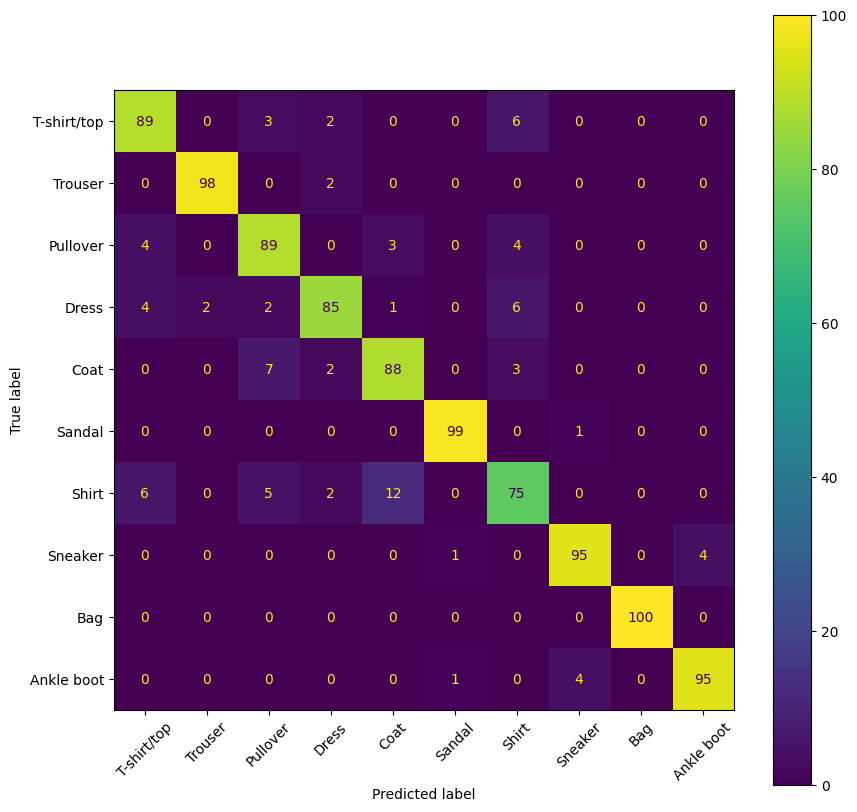

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


outputs = trainer.predict(subset_test_dataset)
print(outputs)

y_true = outputs.label_ids
y_pred = outputs.predictions.argmax(1)

labels = list(classes)
matrix = confusion_matrix(y_true, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=labels)
_, ax = plt.subplots(figsize=(10, 10))
display.plot(xticks_rotation=45, ax=ax)
plt.show()

# 정리

- 일반화 성능이 좋은 모델: CvT
- 모델 크기 대비 가장 우수한 성능: 스윈 트랜스포머
- F1-score 가장 높은 모델 ViT